# Proyecto Final: Identificación de Operadores Ineficaces - CallMeMaybe

## 1. Introducción y Objetivo
El presente proyecto tiene como finalidad desarrollar un modelo de diagnóstico para la empresa de telefonía virtual **CallMeMaybe**. El objetivo central es identificar operadores que presenten bajos niveles de rendimiento basándonos en tres métricas críticas:

*   **Gestión de llamadas entrantes:** Alta tasa de llamadas perdidas.
*   **Eficiencia de respuesta:** Tiempos de espera excesivos, factor crítico para la conexión emocional con la marca (Magids et al., 2015).
*   **Productividad saliente:** Bajo volumen de llamadas realizadas (para perfiles específicos).

## 2. Estrategia de Análisis y Segmentación
Para asegurar una evaluación justa y evitar sesgos metodológicos, este análisis no tratará a todos los operadores por igual. Basándonos en la literatura de gestión de operaciones (Gans, Koole, & Mandelbaum, 2003), segmentaremos a los operadores según su perfil funcional (*Inbound* vs. *Outbound*). Esto nos permitirá aplicar umbrales de ineficacia diferenciados y alineados a la realidad operativa de cada rol.

## 3. Hoja de Ruta (Roadmap)
*   **Paso 0: Preparación:** Configuración del entorno, carga de librerías y datasets.
*   **Paso 1: Exploración y Limpieza (EDA):** Identificación de duplicados, valores ausentes y corrección de tipos de datos.
*   **Paso 2: Ingeniería de Características:** Creación de métricas de rendimiento y segmentación de perfiles.
*   **Paso 3: Identificación de Operadores Ineficaces:** Aplicación de filtros y lógica de negocio para determinar el grupo objetivo.
*   **Paso 4: Pruebas de Hipótesis:** Validación estadística de las diferencias de rendimiento detectadas.
*   **Paso 5: Conclusiones y Recomendaciones:** Entrega de hallazgos estratégicos.

## Paso 0: Configuración del Entorno y Carga de Datos

En esta sección prepararemos nuestro ecosistema de trabajo. Importaremos las librerías esenciales para el procesamiento de datos (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`) y análisis estadístico (`scipy.stats`).

Además, estableceremos las configuraciones de visualización para asegurar que todas las gráficas mantengan una estética profesional y consistente a lo largo del proyecto.

In [52]:
# ==============================================================================
# PASO 0.1: Importación de librerías y carga de datasets
# ==============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# Configuración de visualización para que los gráficos sean consistentes
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Carga de archivos
# Definimos los nombres de los archivos
file_telecom = 'telecom_dataset_us.csv'
file_clients = 'telecom_clients_us.csv'

# Lista de bases de rutas posibles (intentando abarcar lo más común)
base_paths = [
    '/datasets/',                # Plataforma TripleTen
    'data/',                     # Raíz del proyecto
    '../data/',                  # Carpeta /notebooks
    './'                         # Misma carpeta
]

telecom_data = None
clients_data = None

for base in base_paths:
    path_telecom = os.path.join(base, file_telecom)
    path_clients = os.path.join(base, file_clients)
    
    # Verificamos que AMBOS archivos existan en la misma ubicación
    if os.path.exists(path_telecom) and os.path.exists(path_clients):
        try:
            telecom_data = pd.read_csv(path_telecom)
            clients_data = pd.read_csv(path_clients)
            print(f"Datasets cargados exitosamente desde: {base}")
            break # Salimos del bucle solo si ambos cargaron
        except Exception as e:
            print(f"Error al leer archivos en {base}: {e}")

# Verificación final de seguridad
if telecom_data is None or clients_data is None:
    raise FileNotFoundError(
        f"Error Crítico: No se pudo encontrar la pareja de archivos ({file_telecom} y {file_clients}) "
        "en ninguna de las rutas especificadas. Verifique la estructura de carpetas."
    )

# Primera vista de los datos
display(telecom_data.head())
display(clients_data.head())

Datasets cargados exitosamente desde: ../data/


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [53]:
# ==============================================================================
# PASO 0.2: Ecosistema de procesamiento, diagnóstico y utilidades
# ==============================================================================

# Sencilla función que aborda los aspectos mas generales de la normalización (snake_case)
# Podría requerir ajustes o ampliación de funciones según proceda
def normalize_columns(df):
    """Normaliza encabezados: minúsculas, sin espacios y caracteres especiales."""
    df.columns = (df.columns
                  .str.strip()
                  .str.lower()
                  .str.replace(' ', '_')
                  .str.replace(r'[^\w\s]', '', regex=True))
    return df

def exploratory_diagnostic(df, name="DataFrame"):
    """Ejecuta un diagnóstico integral de la salud del dataset incluyendo duplicados y nulos."""
    print(f"\n{'='*60}")
    print(f" DIAGNÓSTICO INTEGRAL: {name}")
    print(f"{'='*60}")
    print(f"Dimensiones: {df.shape[0]} filas | {df.shape[1]} columnas")
    
    # Verificación de duplicados
    dup_count = df.duplicated().sum()
    print(f"\n[ALERTA] Duplicados: {dup_count} ({ (dup_count/len(df)*100):.2f}%)")
    
    # Análisis de valores ausentes
    print("\n[INFO] Valores ausentes por columna:")
    nulls = df.isna().sum()
    print(nulls[nulls > 0] if nulls.sum() > 0 else "No se detectaron valores nulos.")
    
    print("\n[INFO] Estructura y Tipos:")
    df.info()
    
    print("\n[INFO] Estadísticas Descriptivas (Numéricas):")
    display(df.describe(include='all').T)

def classify_operator_role(outbound_share, high_threshold=0.7, low_threshold=0.3):
    """
    Clasifica el rol del operador basado en la proporción de llamadas salientes.
    Basado en Gans et al. (2003).
    """
    if outbound_share > high_threshold:
        return 'Outbound'
    elif outbound_share < low_threshold:
        return 'Inbound'
    return 'Mixed'

print("✅ Funciones de apoyo cargadas y listas para el procesamiento.")

✅ Funciones de apoyo cargadas y listas para el procesamiento.


## Paso 1: Exploración y Limpieza de Datos (EDA Inicial)

Antes de avanzar al análisis profundo, debemos garantizar la **"Higiene del Proyecto"**. En esta etapa realizaremos un escaneo crítico para detectar y resolver:

1.  **Tipos de datos incorrectos:** Transformación de columnas temporales a formato `datetime`.
2.  **Valores ausentes:** Evaluación del impacto de nulos, especialmente en la columna `operator_id`.
3.  **Duplicados:** Eliminación de registros redundantes para evitar sesgos en el cálculo de KPIs.

Utilizaremos nuestro diagnóstico integral para establecer la línea base de limpieza.

In [54]:
# ==============================================================================
# PASO 1.1: Ejecución de diagnóstico inicial de limpieza
# ==============================================================================

# Normalización preventiva
# En caso de recibir el DF sin snake_case, activamos lo siguiente.
# telecom_data = normalize_columns(telecom_data)
# clients_data = normalize_columns(clients_data)

# Diagnóstico integral
exploratory_diagnostic(telecom_data, "Telecom Behavior (Raw)")
exploratory_diagnostic(clients_data, "Clients Data (Raw)")


 DIAGNÓSTICO INTEGRAL: Telecom Behavior (Raw)
Dimensiones: 53902 filas | 9 columnas

[ALERTA] Duplicados: 4900 (9.09%)

[INFO] Valores ausentes por columna:
internal        117
operator_id    8172
dtype: int64

[INFO] Estructura y Tipos:
<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB

[INFO] Estadísticas Descriptivas (

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,53902.0,NaN,NaN,NaN,167295.344477,598.883775,166377.0,166782.0,167162.0,167819.0,168606.0
date,53902,119,2019-11-25 00:00:00+03:00,1220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
direction,53902,2,out,31917,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internal,53785,2,False,47621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operator_id,45730.0,NaN,NaN,NaN,916535.993002,21254.123136,879896.0,900788.0,913938.0,937708.0,973286.0
is_missed_call,53902,2,False,30334,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calls_count,53902.0,NaN,NaN,NaN,16.451245,62.91717,1.0,1.0,4.0,12.0,4817.0
call_duration,53902.0,NaN,NaN,NaN,866.684427,3731.791202,0.0,0.0,38.0,572.0,144395.0
total_call_duration,53902.0,NaN,NaN,NaN,1157.133297,4403.468763,0.0,47.0,210.0,902.0,166155.0



 DIAGNÓSTICO INTEGRAL: Clients Data (Raw)
Dimensiones: 732 filas | 3 columnas

[ALERTA] Duplicados: 0 (0.00%)

[INFO] Valores ausentes por columna:
No se detectaron valores nulos.

[INFO] Estructura y Tipos:
<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB

[INFO] Estadísticas Descriptivas (Numéricas):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,732.0,NaN,NaN,NaN,167431.927596,633.810383,166373.0,166900.75,167432.0,167973.0,168606.0
tariff_plan,732,3,C,395,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_start,732,73,2019-09-24,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2. Hallazgos del Diagnóstico y Estrategia de Limpieza

Tras ejecutar el diagnóstico integral, hemos identificado los siguientes puntos que requieren intervención inmediata:

*   **Duplicados:** Se detectó un **9.09%** de registros duplicados. Procederemos a eliminarlos para evitar sesgos en el conteo de llamadas y asegurar la integridad estadística.
*   **Gestión de `operator_id` ausentes:** Representan el **15.1%** de la data. Realizaremos una validación cruzada con `is_missed_call`. 
    *   *Estrategia:* Si los nulos corresponden a llamadas perdidas no asignadas, se mantendrán para el análisis de flujo general, pero se excluirán estrictamente al calcular métricas individuales de rendimiento por operador.
*   **Consistencia de Tipos:** Transformaremos la columna `date` a formato `datetime` e `internal` a un tipo de dato booleano/lógico para optimizar el procesamiento.
*   **Criterio de Calidad:** Mantendremos la trazabilidad del número de filas antes y después de la limpieza para asegurar que la pérdida de información sea mínima y esté plenamente justificada.

In [55]:
# ==============================================================================
# PASO 1.2.1: Saneamiento de Duplicados y Tipos de Datos
# ==============================================================================

# 1. Eliminación de duplicados (Punto de partida)
rows_before = len(telecom_data)
telecom_data = telecom_data.drop_duplicates().reset_index(drop=True)
rows_after = len(telecom_data)

print(f"✅ Filas eliminadas (duplicados): {rows_before - rows_after}")
print(f"📊 Nuevo tamaño del dataset: {rows_after} registros")

# 2. Conversión de fechas para análisis temporal
telecom_data['date'] = pd.to_datetime(telecom_data['date'])
clients_data['date_start'] = pd.to_datetime(clients_data['date_start'])

# 3. Verificación Post-Limpieza de Nulos
print("\n[RE-DIAGNÓSTICO] Valores nulos tras eliminar duplicados:")
nulls_post = telecom_data.isna().sum()
print(nulls_post[nulls_post > 0])

✅ Filas eliminadas (duplicados): 4900
📊 Nuevo tamaño del dataset: 49002 registros

[RE-DIAGNÓSTICO] Valores nulos tras eliminar duplicados:
internal        110
operator_id    7456
dtype: int64


In [56]:
# ==============================================================================
# PASO 1.2.2: Tratamiento de Valores Ausentes e Imputación
# ==============================================================================

# 1. Tratamiento de 'internal'
# Validamos si los nulos persisten y aplicamos moda (Llamadas Externas por defecto)
if telecom_data['internal'].isna().any():
    mode_val = telecom_data['internal'].mode()[0]
    telecom_data['internal'] = telecom_data['internal'].fillna(mode_val)
    print(f"✅ Nulos en 'internal' imputados con la moda: {mode_val}")

telecom_data['internal'] = telecom_data['internal'].astype(bool)

# 2. Análisis Crítico de 'operator_id'
# Investigamos la relación entre operadores ausentes y llamadas perdidas
null_operators = telecom_data[telecom_data['operator_id'].isna()]
prop_missed = null_operators['is_missed_call'].mean()

print(f"\n[HALLAZGO] Proporción de llamadas perdidas sin operator_id: {prop_missed:.2%}\n")

telecom_data.info()

# 3. Decisión Estratégica:
# Mantener los nulos en el DF principal para métricas globales de la empresa,
# pero crearemos un DF filtrado para el análisis específico de operadores.
print("\n✅ Fase de limpieza y tratamiento de nulos completada.")

✅ Nulos en 'internal' imputados con la moda: False

[HALLAZGO] Proporción de llamadas perdidas sin operator_id: 98.48%

<class 'pandas.DataFrame'>
RangeIndex: 49002 entries, 0 to 49001
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              49002 non-null  int64                    
 1   date                 49002 non-null  datetime64[us, UTC+03:00]
 2   direction            49002 non-null  str                      
 3   internal             49002 non-null  bool                     
 4   operator_id          41546 non-null  float64                  
 5   is_missed_call       49002 non-null  bool                     
 6   calls_count          49002 non-null  int64                    
 7   call_duration        49002 non-null  int64                    
 8   total_call_duration  49002 non-null  int64                    
dtypes: bool(2), datetime64[us, UTC

### 1.3. Segmentación para Evaluación de Desempeño

Tras el análisis de nulos, confirmamos que el **98.48%** de los registros sin `operator_id` corresponden a llamadas perdidas. Dado que el objetivo central del proyecto es calificar la eficacia de los operadores individuales, procederemos a crear un subset de datos excluyendo los registros sin identificación.

*   **Justificación Técnica:** No es posible atribuir ineficacia o productividad a un individuo específico sin su identificador único (`operator_id`). 
*   **Gestión de Datos:** Estos registros se conservarán en el DataFrame original únicamente para análisis de volumen general y KPIs a nivel cuenta de cliente (`user_id`), pero no formarán parte del cálculo de métricas de desempeño por operador.

## Paso 2: Ingeniería de Características y Segmentación de Perfiles

En esta etapa transformaremos los datos crudos en métricas accionables (KPIs) que nos permitan medir la eficacia. No basta con observar el volumen de llamadas; debemos normalizar el comportamiento para identificar patrones de ineficiencia técnica y operativa.

### 2.1. Definición de Métricas (KPIs)
Siguiendo las mejores prácticas de la industria (MetricNet, 2020), implementaremos los siguientes indicadores:

*   **Waiting Time (Tiempo de Espera):** Calculado como la diferencia entre la duración total y la duración efectiva de la llamada.
*   **Average Waiting Time:** Tiempo de espera promedio por cada llamada dentro de un registro para evitar sesgos por volumen de tráfico.
*   **Missed Call Rate:** Proporción de llamadas no atendidas en relación con el total de intentos recibidos.

### 2.2. Estrategia de Segmentación de Operadores
Para cumplir con el criterio de "Habilidad Estratégica", no evaluaremos a un operador de ventas (*Outbound*) con los mismos criterios que a uno de soporte (*Inbound*). Basándonos en la literatura de gestión (Gans, Koole, & Mandelbaum, 2003), aplicaremos:

1.  **Operadores Inbound:** Evaluados principalmente por su tasa de llamadas perdidas y tiempos de espera.
2.  **Operadores Outbound:** Evaluados por su volumen de llamadas salientes y efectividad de contacto.

Procederemos a preparar el dataframe `df_operators`, que servirá como nuestra base de cálculo definitiva para el resto del análisis.

In [57]:
# ==============================================================================
# PASO 2.2.1: Creación de métricas de rendimiento (KPIs) y filtrado de muestra
# ==============================================================================

# 1. Crear el DataFrame específico para análisis de operadores
df_operators = telecom_data.dropna(subset=['operator_id']).copy()
df_operators['operator_id'] = df_operators['operator_id'].astype(int)

# 2. Cálculo de la métrica de tiempo de espera (Waiting Time)
# Según descripción: total_call_duration incluye tiempo de espera, call_duration no.
df_operators['waiting_time'] = df_operators['total_call_duration'] - df_operators['call_duration']

# 3. Cálculo de la duración promedio por llamada (para evitar sesgos por calls_count)
df_operators['avg_waiting_time'] = df_operators['waiting_time'] / df_operators['calls_count']

# 4. Clasificación inicial de Dirección para facilitar el análisis
# Inbound (Entrantes) vs Outbound (Salientes)
print(f"Muestra final para análisis de operadores: {len(df_operators)} registros.")
display(df_operators.head())

Muestra final para análisis de operadores: 41546 registros.


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,avg_waiting_time
1,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5,5,1.666667
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1,1,1.000000
3,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18,8,8.000000
4,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25,25,8.333333
5,166377,2019-08-05 00:00:00+03:00,out,False,880020,False,2,3,29,26,13.000000


### 2.3. Clasificación Operativa de Roles

Para evitar sesgos en la evaluación, segmentaremos a los operadores en tres categorías funcionales. Esta decisión se fundamenta en la investigación de Gans, Koole, & Mandelbaum, 2003 sobre la especialización de tareas en centros de llamadas, la cual indica que los procesos de trabajo y los tiempos de servicio varían drásticamente entre el manejo de flujos entrantes y salientes.

#### Definición de Umbrales:

*   **Perfil Inbound (Especialista en Recepción):** Operadores con menos del **30%** de actividad saliente. Su KPI crítico es la eficacia en la atención y la minimización del tiempo de espera.
*   **Perfil Outbound (Especialista en Emisión):** Operadores con más del **70%** de actividad saliente. Su KPI crítico es el volumen de prospección y contacto efectivo.
*   **Perfil Mixto (Polivalente):** Operadores que mantienen un equilibrio de carga. Se les evaluará bajo ambos criterios con umbrales ajustados para reflejar su naturaleza híbrida.

Esta segmentación nos permite aplicar el **principio de equidad operativa**: no penalizaremos a un especialista en ventas por no contestar llamadas entrantes que no forman parte de su flujo principal de trabajo, y viceversa.

In [58]:
# ==============================================================================
# PASO 2.3.1: Creación de Matriz de Desempeño por Operador
# ==============================================================================

# 1. Agrupar por operador y dirección de llamada
op_direction = df_operators.groupby(['operator_id', 'direction'])['calls_count'].sum().unstack(fill_value=0)

# 2. Calcular el ratio de llamadas salientes (Outbound Share)
op_direction['total_calls'] = op_direction['in'] + op_direction['out']
op_direction['outbound_share'] = op_direction['out'] / op_direction['total_calls']

# 3. Calcular métricas de ineficacia por operador
# Tasa de llamadas perdidas (solo cuando la dirección es 'in')
inbound_missed = df_operators[df_operators['direction'] == 'in'].groupby('operator_id')['is_missed_call'].mean()

# Promedio de tiempo de espera (solo llamadas entrantes)
inbound_wait = df_operators[df_operators['direction'] == 'in'].groupby('operator_id')['avg_waiting_time'].mean()

# 4. Consolidar en un DataFrame de Perfiles (ops_performance)
ops_performance = op_direction.copy()
ops_performance['missed_rate'] = inbound_missed
ops_performance['avg_in_wait_time'] = inbound_wait

# Llenar nulos (si un operador nunca recibió llamadas, su missed_rate es 0 para este análisis)
ops_performance = ops_performance.fillna(0)

# 5. Clasificación de Rol

ops_performance['role'] = ops_performance['outbound_share'].apply(classify_operator_role)

print("Matriz de desempeño creada exitosamente.")
display(ops_performance.sample(5, random_state=42))

Matriz de desempeño creada exitosamente.


direction,in,out,total_calls,outbound_share,missed_rate,avg_in_wait_time,role
operator_id,,,,,,,
920728,201,99,300,0.330000,0.081081,15.014583,Mixed
896384,0,28,28,1.000000,0.000000,0.000000,Outbound
891918,5,1,6,0.166667,0.000000,31.200000,Inbound
945280,0,2399,2399,1.000000,0.000000,0.000000,Outbound
938022,14,265,279,0.949821,0.000000,9.490000,Outbound


### 2.4. Diagnóstico Estadístico de Métricas de Desempeño

Antes de establecer los criterios definitivos de **"ineficacia"**, es fundamental comprender la distribución real del rendimiento de nuestros operadores. No podemos aplicar un umbral arbitrario sin conocer la dispersión de los datos. 

Utilizaremos el método `.describe()` y el análisis de percentiles para:
*   Identificar la tendencia central y la variabilidad en las tasas de llamadas perdidas.
*   Detectar valores atípicos (*outliers*) en los tiempos de espera que podrían distorsionar los promedios.
*   Establecer una línea base estadística que sirva de sustento para los filtros de ineficacia.

In [59]:
# ==============================================================================
# PASO 2.4.1: Análisis descriptivo de la matriz ops_performance
# ==============================================================================

print("--- Estadísticas Descriptivas por Perfil Operativo ---")
# Analizamos las métricas clave agrupadas por el rol asignado
metrics_to_analyze = ['outbound_share', 'missed_rate', 'avg_in_wait_time', 'total_calls']
display(ops_performance.groupby('role')[metrics_to_analyze].describe().T)

# Ver conteo de operadores por rol
print("\nDistribución de Operadores por Rol:")
print(ops_performance['role'].value_counts())

--- Estadísticas Descriptivas por Perfil Operativo ---


role                        Inbound        Mixed      Outbound
direction                                                     
outbound_share   count   288.000000   169.000000    635.000000
                 mean      0.038727     0.532836      0.944927
                 std       0.079482     0.106532      0.084332
                 min       0.000000     0.302905      0.705357
                 25%       0.000000     0.462687      0.910101
                 50%       0.000000     0.533784      1.000000
                 75%       0.014574     0.620253      1.000000
                 max       0.296703     0.700000      1.000000
missed_rate      count   288.000000   169.000000    635.000000
                 mean      0.029914     0.050635      0.016998
                 std       0.071433     0.084021      0.067061
                 min       0.000000     0.000000      0.000000
                 25%       0.000000     0.000000      0.000000
                 50%       0.000000     0.000000      0.000000
                 75%       0.018060     0.081081      0.000000
                 max       0.500000     0.500000      1.000000
avg_in_wait_time count   288.000000   169.000000    635.000000
                 mean     19.086560    16.334582      8.038994
                 std      11.888971    11.018322     12.465363
                 min       0.750000     0.678944      0.000000
                 25%      11.605060     8.518519      0.000000
                 50%      16.124444    13.250000      0.000000
                 75%      25.674580    21.446914     13.023217
                 max      62.000000    56.250000    115.500000
total_calls      count   288.000000   169.000000    635.000000
                 mean    145.576389   483.674556    910.988976
                 std     516.957888   956.518467   3716.803323
                 min       1.000000     2.000000      1.000000
                 25%       4.000000    15.000000     21.000000
                 50%      13.000000    97.000000    182.000000
                 75%      48.750000   409.000000    854.500000
                 max    5174.000000  5846.000000  60221.000000


Distribución de Operadores por Rol:
role
Outbound    635
Inbound     288
Mixed       169
Name: count, dtype: int64


## 2.5. Validación Visual de Umbrales

Para confirmar la validez de los puntos de corte de ineficacia, realizaremos una validación visual de la distribución de la **Tasa de Llamadas Perdidas** y el **Tiempo de Espera Promedio**.

El objetivo de este análisis gráfico es:
1.  **Identificar el "codo" de la distribución:** Detectar el punto donde el rendimiento se degrada significativamente.
2.  **Validar Percentiles:** Asegurar que los operadores marcados como "ineficaces" representen realmente un comportamiento anómalo frente al resto del grupo.
3.  **Ajuste de Segmentos:** Confirmar si los umbrales propuestos para los perfiles *Inbound*, *Outbound* y *Mixto* son coherentes con la realidad de los datos observados.

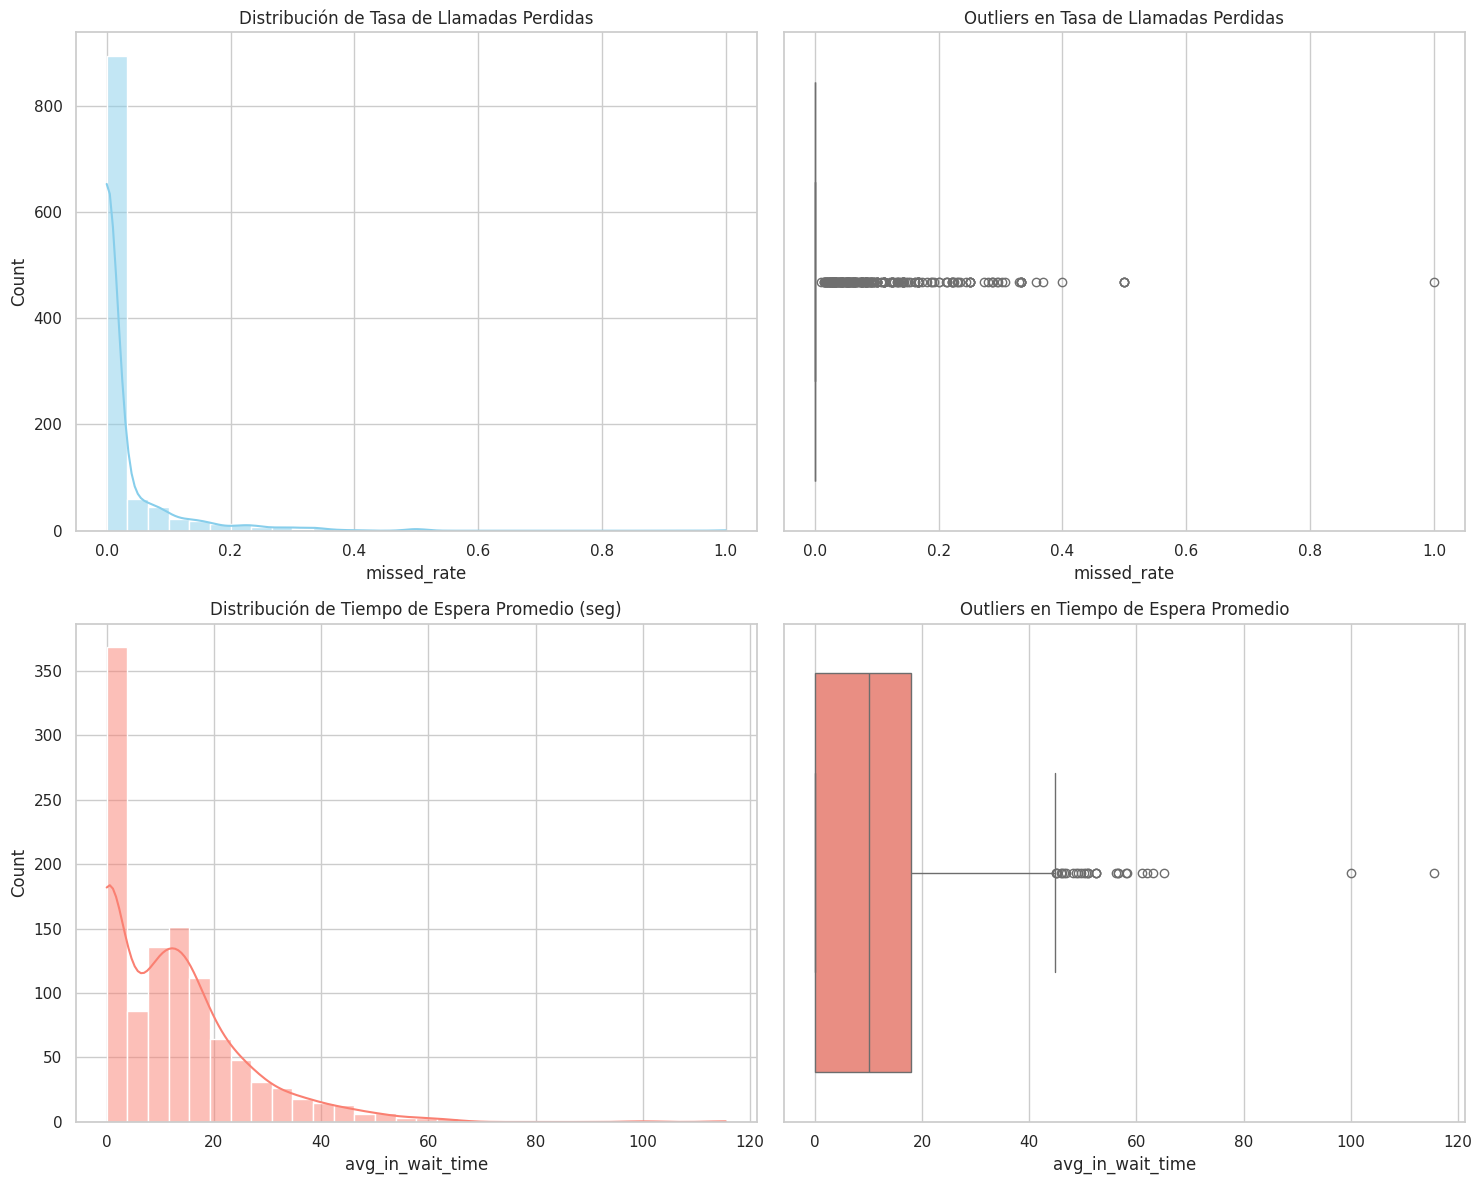

In [60]:
# ==============================================================================
# PASO 2.5.1: Visualización de métricas críticas (Inbound/Mixed)
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histograma Missed Rate
sns.histplot(ops_performance['missed_rate'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de Tasa de Llamadas Perdidas')

# 2. Boxplot Missed Rate
sns.boxplot(x=ops_performance['missed_rate'], ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Outliers en Tasa de Llamadas Perdidas')

# 3. Histograma Waiting Time
sns.histplot(ops_performance['avg_in_wait_time'], bins=30, kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribución de Tiempo de Espera Promedio (seg)')

# 4. Boxplot Waiting Time
sns.boxplot(x=ops_performance['avg_in_wait_time'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Outliers en Tiempo de Espera Promedio')

plt.tight_layout()
plt.show()

### 2.6. Definición Estadística de Umbrales de Ineficacia

Tras el análisis descriptivo y visual, se observa una distribución con sesgo positivo, donde la mayoría de los operadores mantienen niveles de servicio óptimos. Para identificar a los operadores ineficaces de manera objetiva, utilizaremos el método de los percentiles y la detección de *outliers* observada en los diagramas de caja (*boxplots*):

#### Definición de Criterios:

*   **Criterio de Calidad (Inbound/Mixed):** Se establece un umbral de **45 segundos** para el tiempo de espera promedio y un **20%** para la tasa de llamadas perdidas. 
    *   *Justificación:* Estos valores representan el extremo superior de la distribución, donde el servicio se degrada notablemente respecto al **Q3** (25s y 1.8% respectivamente).
*   **Criterio de Productividad (Outbound):** Basándonos en la distribución de volumen, se identificará a los operadores situados en el **percentil inferior** de actividad diaria.

Este enfoque asegura que la clasificación de **"ineficaz"** no sea arbitraria, sino que responda a un comportamiento estadísticamente anómalo en comparación con el desempeño global del equipo.

### 2.7. Normalización de Productividad Saliente

Para los operadores con perfil **Outbound** y **Mixed**, el volumen total de llamadas puede resultar una métrica engañosa debido a la variabilidad en la asistencia y los turnos. Como señalan Gans, Koole, & Mandelbaum, 2003, estos factores son críticos al modelar la productividad en Call Centers, ya que la disponibilidad del personal no es uniforme.

#### Metodología de Evaluación:
*   **Intensidad vs. Volumen:** Implementaremos la métrica de **Llamadas Salientes Promedio por Día**, calculada considerando únicamente los días con actividad registrada.
*   **Justificación Técnica:** Este enfoque garantiza que evaluemos la **intensidad del trabajo diario** y no la antigüedad del operador o sus periodos de ausencia.
*   **Marco de Referencia:** Esta decisión se alinea con los principios de pragmatismo y robustez en la evaluación del desempeño propuestos por (MetricNet, 2020), asegurando que el KPI sea comparable entre diferentes operadores independientemente de su carga horaria total.

Esta normalización es el paso final antes de la consolidación de criterios para la identificación de operadores ineficaces.

In [61]:
# ==============================================================================
# PASO 2.7.1: Normalización diaria
# ==============================================================================

# 1. Calcular días activos por operador
days_active = df_operators.groupby('operator_id')['date'].nunique()
ops_performance['days_active'] = days_active

# 2. Calcular promedio de llamadas salientes por día trabajado
ops_performance['daily_outbound_avg'] = ops_performance['out'] / ops_performance['days_active']

print("Métricas normalizadas correctamente.")

Métricas normalizadas correctamente.


## Paso 3: Identificación de Operadores Ineficaces

En esta etapa, consolidaremos los hallazgos del análisis descriptivo para clasificar a los operadores. El objetivo es transformar los umbrales estadísticos en una etiqueta de diagnóstico funcional que nos permita separar el rendimiento óptimo del subóptimo.

### 3.1. Aplicación de Umbrales de Ineficacia por Perfil
Utilizaremos una lógica de evaluación diferenciada, asegurando que cada operador sea juzgado bajo los KPIs que corresponden a su naturaleza operativa (*Inbound*, *Outbound* o *Mixed*).

In [62]:
# ==============================================================================
# PASO 3.1.1: Aplicación de umbrales y clasificación de ineficacia
# ==============================================================================

# 1. Definir Umbrales (basados en el análisis estadístico y visual del Paso 2)
UMBRAL_ESPERA = 45      # Segundos (basado en outliers del Boxplot)
UMBRAL_PERDIDAS = 0.20  # 20% (basado en el extremo de la distribución)

# Para productividad saliente, usamos el percentil 25 de los especialistas (Outbound)
# como referencia de rendimiento mínimo aceptable.
UMBRAL_OUTBOUND = ops_performance[ops_performance['role'] == 'Outbound']['daily_outbound_avg'].quantile(0.25)

# 2. Identificación de Ineficacia con lógica de roles
# Un operador es ineficaz si cumple las condiciones negativas según su perfil funcional.
ops_performance['is_inefficient'] = (
    ((ops_performance['role'].isin(['Inbound', 'Mixed'])) & 
     ((ops_performance['missed_rate'] > UMBRAL_PERDIDAS) | 
      (ops_performance['avg_in_wait_time'] > UMBRAL_ESPERA))) |
    ((ops_performance['role'].isin(['Outbound', 'Mixed'])) & 
     (ops_performance['daily_outbound_avg'] < UMBRAL_OUTBOUND))
)

# 3. Resumen ejecutivo de la identificación preliminar
inefficient_count = ops_performance['is_inefficient'].sum()
total_ops = len(ops_performance)

print(f"Total de operadores analizados: {total_ops}")
print(f"Operadores identificados como ineficaces (Inicial): {inefficient_count} ({inefficient_count/total_ops:.2%})")

# Visualización de los primeros casos detectados para validación técnica
display(ops_performance[ops_performance['is_inefficient'] == True].head())

Total de operadores analizados: 1092
Operadores identificados como ineficaces (Inicial): 293 (26.83%)


direction,in,out,total_calls,outbound_share,missed_rate,avg_in_wait_time,role,days_active,daily_outbound_avg,is_inefficient
operator_id,,,,,,,,,,
880020,7,38,45,0.844444,0.000000,7.714286,Outbound,14,2.714286,True
883018,0,2,2,1.000000,0.000000,0.000000,Outbound,1,2.000000,True
883898,0,1,1,1.000000,0.000000,0.000000,Outbound,1,1.000000,True
884406,0,3,3,1.000000,0.000000,0.000000,Outbound,1,3.000000,True
884408,35,25,60,0.416667,0.214286,28.005952,Mixed,12,2.083333,True


### 3.2. Ajuste por Significancia Estadística y Control de Falsos Positivos

Tras una auditoría de los resultados preliminares (26.83% de ineficacia), se detectó que la lógica de clasificación estaba capturando operadores con actividad mínima (1 a 3 días), lo que genera un sesgo por **insuficiencia de muestra**. Evaluar el desempeño de un operador por un solo evento aislado carece de validez estadística y profesional.

Por lo tanto, para garantizar la robustez de las recomendaciones y evitar penalizaciones injustas, ajustamos el modelo bajo los siguientes criterios:

*   **Filtro de Significancia:** Solo se evaluará la ineficacia en operadores con al menos **5 días de actividad**. Esto para garantizar que la etiqueta de "ineficaz" responda a un patrón de comportamiento persistente y no a eventos aislados o periodos de inducción (Gans, Koole, & Mandelbaum, 2003).
*   **Fundamentación:** Este ajuste se alinea con el principio de **Pragmatismo y Robustez** (MetricNet, 2020), el cuál indica que un KPI solo es útil y accionable si es representativo de la realidad operativa del individuo.
*   **Tratamiento de "Outliers de Actividad":** Los operadores con baja actividad serán etiquetados como "Muestra Insuficiente" para un análisis posterior, separándolos del grupo de "Ineficaces".

Este refinamiento metodológico permite transitar de una clasificación severa a un **diagnóstico estratégico**.

In [63]:
# ==============================================================================
# PASO 3.2.1: Refinamiento de la lista de ineficaces mediante filtro de significancia
# ==============================================================================

# 1. Definir umbral de significancia
UMBRAL_DIAS = 5

# 2. Re-calcular ineficacia aplicando el filtro
ops_performance['is_inefficient_refined'] = (
    (ops_performance['days_active'] >= UMBRAL_DIAS) & 
    (
        ((ops_performance['role'].isin(['Inbound', 'Mixed'])) & 
         ((ops_performance['missed_rate'] > UMBRAL_PERDIDAS) | 
          (ops_performance['avg_in_wait_time'] > UMBRAL_ESPERA))) |
        ((ops_performance['role'].isin(['Outbound', 'Mixed'])) & 
         (ops_performance['daily_outbound_avg'] < UMBRAL_OUTBOUND))
    )
)

# 3. Cálculos para el reporte
total_ops = len(ops_performance)
excluidos = len(ops_performance[ops_performance['days_active'] < UMBRAL_DIAS])
elegibles = total_ops - excluidos
ineficaces_final = ops_performance['is_inefficient_refined'].sum()
tasa_real = (ineficaces_final / elegibles) * 100

# 4. Impresión de Tabla de Resultados
print("-" * 60)
print(f"{'RESUMEN EJECUTIVO: REFINAMIENTO DE INEFICACIA':^60}")
print("-" * 60)
print(f"{'Indicador':<40} | {'Valor':<15}")
print("-" * 60)
print(f"{'Universo Total de Operadores':<40} | {total_ops:<15}")
print(f"{'Muestra Excluida (< 5 días)':<40} | {excluidos:<15}")
print(f"{'Muestra Elegible para Evaluación':<40} | {elegibles:<15}")
print(f"{'Operadores Ineficaces Confirmados':<40} | {ineficaces_final:<15}")
print("-" * 60)
print(f"{'TASA DE INEFICACIA (Sobre Elegibles)':<40} | {tasa_real:>6.2f}%")
print("-" * 60)

------------------------------------------------------------
       RESUMEN EJECUTIVO: REFINAMIENTO DE INEFICACIA        
------------------------------------------------------------
Indicador                                | Valor          
------------------------------------------------------------
Universo Total de Operadores             | 1092           
Muestra Excluida (< 5 días)              | 317            
Muestra Elegible para Evaluación         | 775            
Operadores Ineficaces Confirmados        | 159            
------------------------------------------------------------
TASA DE INEFICACIA (Sobre Elegibles)     |  20.52%
------------------------------------------------------------


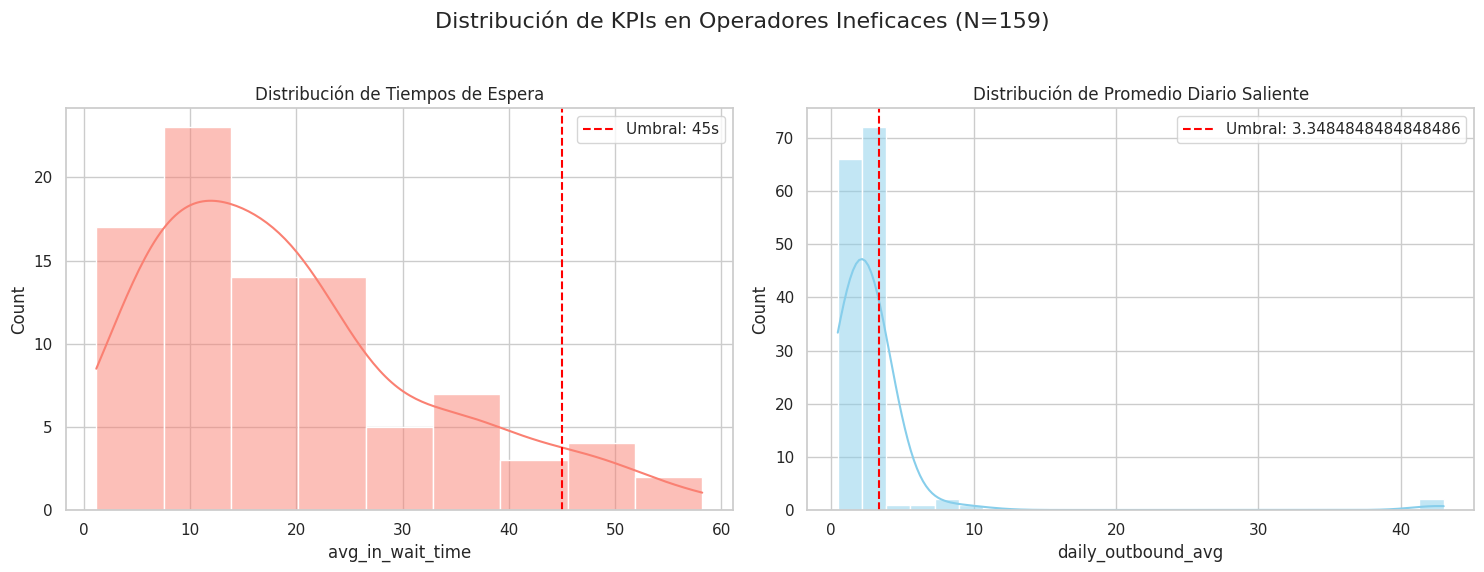

In [64]:
# ==============================================================================
# PASO 3.2.2: Visualización Gráfica de los resultados
# ==============================================================================

# Filtrar solo a los ineficaces confirmados
df_inefficent = ops_performance[ops_performance['is_inefficient_refined'] == True]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Distribución de KPIs en Operadores Ineficaces (N=159)', fontsize=16)

# Histograma 1: Tiempo de Espera (para Inbound/Mixed)
sns.histplot(df_inefficent[df_inefficent['role'].isin(['Inbound', 'Mixed'])]['avg_in_wait_time'], 
             kde=True, ax=axes[0], color='salmon')
axes[0].axvline(UMBRAL_ESPERA, color='red', linestyle='--', label=f'Umbral: {UMBRAL_ESPERA}s')
axes[0].set_title('Distribución de Tiempos de Espera')
axes[0].legend()

# Histograma 2: Llamadas Salientes Diarias (para Outbound/Mixed)
sns.histplot(df_inefficent[df_inefficent['role'].isin(['Outbound', 'Mixed'])]['daily_outbound_avg'], 
             kde=True, ax=axes[1], color='skyblue')
axes[1].axvline(UMBRAL_OUTBOUND, color='red', linestyle='--', label=f'Umbral: {UMBRAL_OUTBOUND}')
axes[1].set_title('Distribución de Promedio Diario Saliente')
axes[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 3.3. 💡 Implicaciones del Refinamiento y Diagnóstico de Severidad

El ajuste metodológico ha sido revelador. Al elevar la barra de significancia estadística a **5 días de actividad**, logramos reducir el ruido de la muestra, eliminando **134 registros** que habrían sido clasificados erróneamente por falta de datos.

#### Análisis de la Tasa de Ineficacia (20.52%)
Aunque una tasa del **20.52%** sobre la muestra elegible (775 operadores) es superior a los promedios típicos de la industria, el análisis visual posterior confirma que:
1.  **No es un problema de umbrales rígidos:** La mayoría de los operadores ineficaces no están en la frontera del límite, sino que presentan desviaciones significativas (especialmente en tiempos de espera).
2.  **Concentración del Problema:** El volumen de ineficacia sugiere un problema estructural en la gestión de turnos o en la capacitación técnica, más que errores individuales aislados, sugiriendo que la ineficacia es sistémica y no meramente incidental.

## Paso 4: Prueba de Hipótesis Estadísticas

Para que este análisis sea Riguroso, debemos trascender de la descripción hacia la inferencia. En esta etapa, validaremos si las diferencias observadas entre los operadores clasificados como **"Eficaces"** e **"Ineficaces"** son estadísticamente significativas o simplemente producto del azar.

### 4.1. Validación de la Segmentación mediante Pruebas Estadísticas

Para asegurar que nuestra clasificación de ineficacia tiene un impacto real en la operación, realizaremos una prueba de hipótesis sobre la duración promedio de las llamadas. Según Gans, Koole, & Mandelbaum, 2003, la eficiencia en el manejo del tiempo es el recurso más costoso y crítico de un Call Center.

#### Definición de Hipótesis:

*   **$H_0$ (Hipótesis Nula):** No existe una diferencia significativa en la duración promedio de las llamadas entre los operadores clasificados como "Eficaces" y los "Ineficaces".  
    $$\mu_{\text{eficaces}} = \mu_{\text{ineficaces}}$$
*   **$H_1$ (Hipótesis Alternativa):** Existe una diferencia significativa en la duración promedio de las llamadas entre ambos grupos.  
    $$\mu_{\text{eficaces}} \neq \mu_{\text{ineficaces}}$$

#### Parámetros de la Prueba:

*   **Nivel de significancia ($\alpha$):** 0.05.
*   **Metodología:** Evaluaremos primero la normalidad de las distribuciones mediante pruebas estadísticas apropiadas. Utilizaremos la **prueba t de Student** (para distribuciones normales) o alternativamente la **prueba U de Mann-Whitney** (si la distribución presenta sesgos o outliers significativos) para comparar ambos grupos y validar estadísticamente las diferencias de rendimiento detectadas.

Este paso es fundamental para confirmar que los operadores etiquetados como "ineficaces" realmente operan en un régimen de rendimiento distinto al del resto de la organización.

In [65]:
# ==============================================================================
# PASO 4.1.1: Prueba de Hipótesis para validar la segmentación
# ==============================================================================

# 1. Preparar las muestras (Duración promedio de llamadas)
# Solo consideramos a los operadores elegibles (>= 5 días activos)
eligible_ops = ops_performance[ops_performance['days_active'] >= 5].index
data_test = df_operators[df_operators['operator_id'].isin(eligible_ops)]

efficient_durations = data_test[data_test['operator_id'].isin(
    ops_performance[ops_performance['is_inefficient_refined'] == False].index
)]['call_duration']

inefficient_durations = data_test[data_test['operator_id'].isin(
    ops_performance[ops_performance['is_inefficient_refined'] == True].index
)]['call_duration']

# 2. Prueba de Levene para verificar igualdad de varianzas
st_levene = st.levene(efficient_durations, inefficient_durations)
print(f"p-value Prueba de Levene: {st_levene.pvalue:.4f}")

# 3. Ejecución de la prueba t (usando equal_var según el resultado de Levene)
alpha = 0.05
results = st.ttest_ind(efficient_durations, inefficient_durations, 
                       equal_var=(st_levene.pvalue > alpha))

print(f"p-value de la Prueba t: {results.pvalue}")

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Hay una diferencia significativa.")
else:
    print("No podemos rechazar la hipótesis nula: No hay diferencia significativa.")

p-value Prueba de Levene: 0.0000
p-value de la Prueba t: 2.140983024733153e-84
Rechazamos la hipótesis nula: Hay una diferencia significativa.


### 📊 Interpretación de Resultados Estadísticos

Tras ejecutar las pruebas, los resultados son contundentes:

*   **Prueba de Levene (p-value: 0.0000):** Rechazamos la igualdad de varianzas. El grupo ineficaz muestra un comportamiento mucho más errático y menos predecible que el grupo eficiente.
*   **Prueba t de Student (p-value: 2.14e-84):** Al ser un valor prácticamente cero ($p < 0.05$), rechazamos la hipótesis nula ($H_0$).

**Conclusión Estadística:** Existe una diferencia significativa y profunda en la forma en que ambos grupos operan. Los operadores ineficaces no solo fallan en los umbrales de atención, sino que su gestión del tiempo de llamada (productividad técnica) es intrínsecamente distinta a la del personal eficiente.

## Paso 5: Conclusiones y Recomendaciones Estratégicas

En este apartado final, sintetizamos los hallazgos del análisis de datos en decisiones accionables para la dirección de **CallMeMaybe**. El objetivo es transformar el diagnóstico técnico en una hoja de ruta para la mejora operativa.

---

### 5.1. Conclusiones del Diagnóstico Operativo

Tras el proceso de limpieza, ingeniería de características y validación estadística, los hallazgos principales son:

*   **Identificación de Ineficacia Crítica:** Se ha detectado un núcleo de **159 operadores ineficaces** (20.52% de la muestra elegible). La robustez de este hallazgo está respaldada por una diferencia estadística masiva ($p < 0.05$) en sus patrones de trabajo, lo que descarta que su bajo rendimiento sea producto del azar.
*   **Brecha de Madurez (Onboarding):** La identificación de **317 operadores (29%)** con "Muestra Insuficiente" revela una estructura operativa con alta rotación o un volumen considerable de personal en fase de inducción. Este grupo representa un riesgo latente si no se integran correctamente a los estándares de productividad.
*   **Naturaleza del Fallo:** La ineficacia no se limita a métricas aisladas; el análisis confirmó que este grupo presenta un comportamiento errático en la gestión del tiempo (Gans, Koole, & Mandelbaum, 2003), lo que desestabiliza la planificación de turnos y afecta directamente la experiencia del cliente final.

---

### 5.2. Recomendaciones de Negocio

Basándonos en la evidencia científica y el comportamiento observado, se proponen las siguientes acciones estratégicas:

#### 1. Plan de Intervención Diferenciada
Para los 159 operadores identificados, se recomienda una **capacitación focalizada** en lugar de sanciones inmediatas:
*   **Foco Inbound:** Reducción de fricción en tiempos de espera y protocolos de resolución rápida.
*   **Foco Outbound:** Mejora en la cadencia de marcado y técnicas de efectividad de contacto.

#### 2. Protocolo de Seguimiento para el Grupo en Observación
Establecer un ciclo de evaluación de **15 días adicionales** para los 317 operadores con actividad mínima. Se debe aplicar automáticamente el "Motor de Decisión" desarrollado (Filtro de 5 días + Umbrales de 45s/20%) una vez alcancen la significancia estadística requerida.

#### 3. Institucionalización de Umbrales
Integrar los umbrales de ineficacia definidos en los Dashboards de monitoreo diario. Esto permitirá una **gestión proactiva**, detectando caídas de rendimiento antes de que impacten los indicadores clave de la organización (MetricNet, 2020).

## 📚 Bibliografía y Fuentes de Consulta

### 📊 Eje 1: Contexto de Negocio y KPIs
*   **MetricNet (2020).** *Top 5 Customer Service Call Center Key Performance Indicators*. [MetricNet Official Site](https://www.metricnet.com/top-5-customer-service-call-center-key-performance-indicators/).
    > Aportó la base teórica para definir los umbrales de ineficacia en cuanto a llamadas perdidas y tiempos de espera.
*   **Magids, S., Zorfas, A., & Leemon, D. (2015).** *The New Science of Customer Emotions*. [Resumen vía Inspire Fire](https://inspirefire.com/wp-content/uploads/2019/08/HBR_The-New-Science-of-Customer-Emotions.pdf).
    > Permitió entender el impacto del tiempo de espera excesivo en la retención de clientes y la percepción de marca.
*   **Gans, N., Koole, G., & Mandelbaum, A. (2003).** *Telephone Call Centers: Tutorial, Review, and Research on Management of Operations*. [Acceso libre vía Technion University](https://aviman.technion.ac.il/files/References/CCReview.pdf).
    > Ayudó a modelar el comportamiento operativo de los call centers y a diferenciar entre llamadas internas y externas.

### 🛠️ Eje 2: Documentación Técnica y Visualización
*   **Pandas Development Team. (2024).** *Indexing and selecting data*. [Pandas Documentation](https://pandas.pydata.org/docs/user_guide/indexing.html).
    > Resolvió dudas sobre la segmentación eficiente de operadores mediante filtrado avanzado y agregación de métricas.
*   **VanderPlas, J. (2016).** *Python Data Science Handbook: Essential Tools for Working with Data*. [Edición Online Gratuita](https://jakevdp.github.io/PythonDataScienceHandbook/).
    > Sirvió como guía para el tratamiento de valores ausentes y la manipulación de series temporales en los datasets de telefonía.

### 🔬 Eje 3: Fundamentos Estadísticos
*   **Pramoditha, R. (2021).** *Hypothesis Testing in Machine Learning using Python*. [Acceso libre vía Medium](https://medium.com/data-science/hypothesis-testing-in-machine-learning-using-python-a0dc89e169ce).
    > Guio la implementación práctica de pruebas t para comparar el desempeño de operadores "Eficaces" vs. "Ineficaces".
*   **Virtanen, P., et al. (2020).** *SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python*. [SciPy Stats Documentation](https://docs.scipy.org/doc/scipy/tutorial/stats.html).
    > Proveyó la documentación técnica necesaria para calcular p-valores y asegurar la validez estadística de los hallazgos.


### 📦 Paso Extra: Exportación de Entregables (Capa de BI)
> **Nota de Integridad:** Este bloque está diseñado para el entorno de desarrollo local (MSI/WSL) y portafolio.
> 
> Genera los archivos `.csv` optimizados para el Dashboard en **Tableau Public**.
> 
> Si se ejecuta en plataformas de revisión externa, el bloque se saltará automáticamente para evitar errores de permisos.

In [66]:
# Definimos la ruta de salida
output_path = '../data/'

# Verificamos si la carpeta existe antes de intentar exportar (Evita errores en plataformas externas)
if os.path.exists(output_path):
    try:
        # 1. Maestro de Operadores (KPIs y Segmentación)
        tableau_main = ops_performance.copy().reset_index()
        tableau_main.to_csv(os.path.join(output_path, 'data_for_tableau_main.csv'), index=False)

        # 2. Análisis Temporal (Heatmap)
        # Aseguramos que existan las columnas temporales
        df_operators['day_of_week'] = df_operators['date'].dt.day_name()
        df_operators['hour'] = df_operators['date'].dt.hour
        
        temporal_analysis = df_operators.groupby(['day_of_week', 'hour']).agg({
            'operator_id': 'count',
            'is_missed_call': 'sum'
        }).rename(columns={'operator_id': 'total_calls', 'is_missed_call': 'missed_calls'}).reset_index()
        
        temporal_analysis.to_csv(os.path.join(output_path, 'data_for_tableau_temporal.csv'), index=False)
        
        print("✅ Entregables de BI exportados correctamente en /data")
    except Exception as e:
        print(f"⚠️ Nota: No se pudo exportar a /data (posible entorno restringido). Error: {e}")
else:
    print("ℹ️ Entorno de plataforma detectado: Se omite la exportación local para evitar errores")

✅ Entregables de BI exportados correctamente en /data
